## Appendix D : Data Wrangling notebook

In [1]:
#!pip install pandas
#!pip install geopandas
#!pip install matplotlib 
#!pip install contextily

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# Lower Layer Super Output Areas

In [3]:
LSOA_boundaries = gpd.read_file("Raw_data/Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BGC_V5_7754846390388463624/LSOA_2021_EW_BGC_V5.shp")

In [4]:
LSOA_boundaries.head(3)

,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,E01000001,City of London 001A,None,532123,181632,51.5182,-0.09715,86214465-5cf4-4e8f-9492-3667471c42d6,"POLYGON ((532105.312 182010.574, 532162.491 18..."
1,E01000002,City of London 001B,None,532480,181715,51.5188,-0.09197,cd40c491-6567-405f-8c18-426e17b356ce,"POLYGON ((532634.497 181926.016, 532619.141 18..."
2,E01000003,City of London 001C,None,532239,182033,51.5217,-0.09533,7fd27aaf-d858-4e46-9099-92b43f66b948,"POLYGON ((532135.138 182198.131, 532158.25 182..."


In [5]:
LSOA_boundaries = LSOA_boundaries[["LSOA21CD", "LSOA21NM","GlobalID", "geometry"]]

In [6]:
LSOA_boundaries.head(3)

,LSOA21CD,LSOA21NM,GlobalID,geometry
0,E01000001,City of London 001A,86214465-5cf4-4e8f-9492-3667471c42d6,"POLYGON ((532105.312 182010.574, 532162.491 18..."
1,E01000002,City of London 001B,cd40c491-6567-405f-8c18-426e17b356ce,"POLYGON ((532634.497 181926.016, 532619.141 18..."
2,E01000003,City of London 001C,7fd27aaf-d858-4e46-9099-92b43f66b948,"POLYGON ((532135.138 182198.131, 532158.25 182..."


In [7]:
LSOA_boundaries.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 35672 entries, 0 to 35671
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   LSOA21CD  35672 non-null  object  
 1   LSOA21NM  35672 non-null  object  
 2   GlobalID  35672 non-null  object  
 3   geometry  35672 non-null  geometry
dtypes: geometry(1), object(3)
memory usage: 1.1+ MB


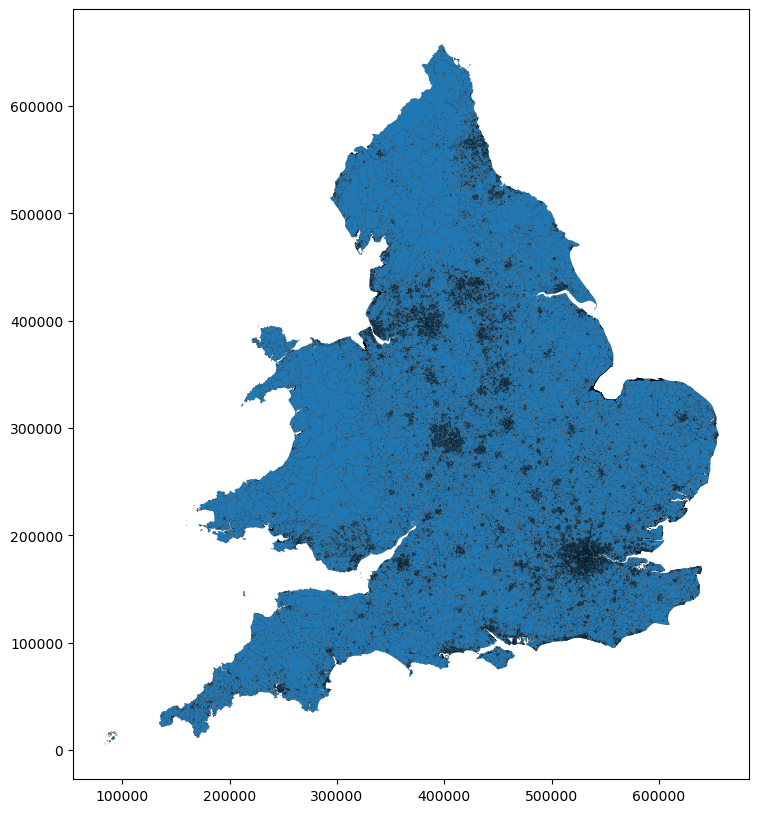

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))

LSOA_boundaries.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.1
)

plt.show()

In [9]:
LSOA_boundaries['LSOA21CD'].str[0].value_counts()

LSOA21CD
E    33755
W     1917
Name: count, dtype: int64

In [10]:
England_LSOA = LSOA_boundaries[LSOA_boundaries['LSOA21CD'].str[0] == 'E']

In [11]:
os.makedirs("Data_Processed/England_LSOA_December_2021_Boundaries", exist_ok=True)
England_LSOA.to_file(
    r"Data_Processed/England_LSOA_December_2021_Boundaries\LSOA.shp",
    driver="ESRI Shapefile"
)

# Population Estimates for Lower layer Super Output Areas in England

In [12]:
Pop =  pd.read_excel("Raw_data/sapelsoasyoa20222024.xlsx", sheet_name="Mid-2024 LSOA 2021", skiprows=3)

In [13]:
Pop.head(3)

,LAD 2023 Code,LAD 2023 Name,LSOA 2021 Code,LSOA 2021 Name,Total,F0,F1,F2,F3,F4,...,M81,M82,M83,M84,M85,M86,M87,M88,M89,M90
0,E06000001,Hartlepool,E01011949,Hartlepool 009A,1898,6,7,16,3,11,...,3,3,4,5,1,1,2,2,2,3
1,E06000001,Hartlepool,E01011950,Hartlepool 008A,1247,11,10,7,14,13,...,0,2,1,0,0,1,0,0,0,0
2,E06000001,Hartlepool,E01011951,Hartlepool 007A,1393,5,11,9,9,12,...,1,0,0,1,3,2,0,1,0,1


In [14]:
# Under 5 years (0–4)
Pop["Female_Under5"] = Pop[[f"F{i}" for i in range(5)]].sum(axis=1)
Pop["Male_Under5"] = Pop[[f"M{i}" for i in range(5)]].sum(axis=1)

# 5–18 years
Pop["Female_5_18"] = Pop[[f"F{i}" for i in range(5, 19)]].sum(axis=1)
Pop["Male_5_18"] = Pop[[f"M{i}" for i in range(5, 19)]].sum(axis=1)

# 19–64 years
Pop["Female_19_64"] = Pop[[f"F{i}" for i in range(19, 65)]].sum(axis=1)
Pop["Male_19_64"] = Pop[[f"M{i}" for i in range(19, 65)]].sum(axis=1)

# 65 years and above
Pop["Female_above65"] = Pop[[f"F{i}" for i in range(65, 91)]].sum(axis=1)
Pop["Male_above65"] = Pop[[f"M{i}" for i in range(65, 91)]].sum(axis=1)

In [15]:
Pop = Pop[
    [
        "LAD 2023 Code",
        "LAD 2023 Name",
        "LSOA 2021 Code",
        "LSOA 2021 Name",
        "Total",
        "Female_Under5",
        "Male_Under5",
        "Female_5_18",
        "Male_5_18",
        "Female_19_64",
        "Male_19_64",
        "Female_above65",
        "Male_above65",
    ]
]


In [16]:
Pop_Match = (
    Pop["Total"] !=
    (
        Pop["Female_Under5"] +
        Pop["Male_Under5"] +
        Pop["Female_5_18"] +
        Pop["Male_5_18"] +
        Pop["Female_19_64"] +
        Pop["Male_19_64"] +
        Pop["Female_above65"] +
        Pop["Male_above65"]
    )
).sum()

print(f"Number of mismatches: {Pop_Match}")

Number of mismatches: 0


In [17]:
Pop.head(3)

,LAD 2023 Code,LAD 2023 Name,LSOA 2021 Code,LSOA 2021 Name,Total,Female_Under5,Male_Under5,Female_5_18,Male_5_18,Female_19_64,Male_19_64,Female_above65,Male_above65
0,E06000001,Hartlepool,E01011949,Hartlepool 009A,1898,43,35,176,217,566,547,179,135
1,E06000001,Hartlepool,E01011950,Hartlepool 008A,1247,55,51,122,107,326,402,103,81
2,E06000001,Hartlepool,E01011951,Hartlepool 007A,1393,46,47,98,114,458,467,85,78


In [18]:
Pop.to_csv("Data_Processed/LSOA_population.csv", index=False)

# Physical Activity levels in Adults 

In [19]:
LSOA_Adults_PA =  pd.read_excel("Raw_data/Small area estimates - adult MSOA and LSOA 23-24 .xlsx", sheet_name="Active LSOA")

In [20]:
LSOA_Adults_PA.head()

,LSOA,MSOA name,LSOA code,All adults,"NS SEC 1-2: managerial, administrative and professional occupations",NS SEC 3: intermediate occupations,NS SEC 4: self employed and small employers,NS SEC 5: lower supervisory and technical occupations,NS SEC 6-7: semi-routine and routine occupations,NS SEC 8: long term unemployed or never worked,...,Disability,No disability,Female,Male,0 inequalities,1 inequality,2 or more inequalities,LA name,LA code,Active Partnership
0,adur 001a,Hillside,E01031349,0.661941,0.741647,0.642490,0.668186,0.636201,0.571146,0.455739,...,0.462914,0.704413,0.635382,0.689910,0.762180,0.647891,0.444731,adur,E07000223,Active Sussex
1,adur 001b,Hillside,E01031350,0.652287,0.743817,0.642489,0.678514,0.649572,0.577450,0.466188,...,0.476664,0.700039,0.624442,0.685095,0.754814,0.638943,0.439282,adur,E07000223,Active Sussex
2,adur 001c,Hillside,E01031351,0.655030,0.737435,0.637906,0.669917,0.638763,0.560527,0.438342,...,0.444937,0.700696,0.625392,0.688130,0.762540,0.640120,0.416772,adur,E07000223,Active Sussex
3,adur 001d,Hillside,E01031352,0.645958,0.733187,0.633966,0.663064,0.627366,0.557896,0.437645,...,0.449406,0.695013,0.622583,0.673320,0.762466,0.642241,0.427230,adur,E07000223,Active Sussex
4,adur 001e,Hillside,E01031370,0.654189,0.745039,0.644298,0.676248,0.654377,0.581430,0.462591,...,0.471500,0.700439,0.626540,0.685088,0.764950,0.649102,0.445692,adur,E07000223,Active Sussex


In [21]:
LSOA_Adults_PA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33755 entries, 0 to 33754
Data columns (total 32 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   LSOA                                                                 33755 non-null  object 
 1   MSOA name                                                            33755 non-null  object 
 2   LSOA code                                                            33755 non-null  object 
 3   All adults                                                           33755 non-null  float64
 4   NS SEC 1-2: managerial, administrative and professional occupations  33755 non-null  float64
 5   NS SEC 3: intermediate occupations                                   33755 non-null  float64
 6   NS SEC 4: self employed and small employers                          33755 non-null  float64
 7   NS S

In [22]:
numeric_cols = LSOA_Adults_PA.select_dtypes(include='number').columns
# percentages
LSOA_Adults_PA[numeric_cols] = LSOA_Adults_PA[numeric_cols] * 100
LSOA_Adults_PA[numeric_cols] = LSOA_Adults_PA[numeric_cols].round(2)

In [23]:
LSOA_Adults_PA.head(3)

,LSOA,MSOA name,LSOA code,All adults,"NS SEC 1-2: managerial, administrative and professional occupations",NS SEC 3: intermediate occupations,NS SEC 4: self employed and small employers,NS SEC 5: lower supervisory and technical occupations,NS SEC 6-7: semi-routine and routine occupations,NS SEC 8: long term unemployed or never worked,...,Disability,No disability,Female,Male,0 inequalities,1 inequality,2 or more inequalities,LA name,LA code,Active Partnership
0,adur 001a,Hillside,E01031349,66.19,74.16,64.25,66.82,63.62,57.11,45.57,...,46.29,70.44,63.54,68.99,76.22,64.79,44.47,adur,E07000223,Active Sussex
1,adur 001b,Hillside,E01031350,65.23,74.38,64.25,67.85,64.96,57.75,46.62,...,47.67,70.00,62.44,68.51,75.48,63.89,43.93,adur,E07000223,Active Sussex
2,adur 001c,Hillside,E01031351,65.50,73.74,63.79,66.99,63.88,56.05,43.83,...,44.49,70.07,62.54,68.81,76.25,64.01,41.68,adur,E07000223,Active Sussex


In [24]:
LSOA_Adults_PA.to_csv("Data_Processed/Adults_PA.csv", index=False)

# Physical Activity levels in Children and Young people 

In [25]:
LSOA_CYP_PA =  pd.read_excel("Raw_data/Children and Young People small area estimates Nov 21-22.xlsx", sheet_name="CYP active LSOA")

In [26]:
LSOA_CYP_PA.head(3)

,LSOA,MSOA name,LSOA code,Active overall,Girl,Boy,Disability or LT Limiting Health Condition,No disability or LT Limiting Health Condition,Asian,Black,...,Ethnicity na,Other ethnicity,White British,White Other,High family affluence,Low family affluence,Medium family affluence,Local authority name,Local authority code,Active Partnership
0,adur 001a,Hillside,E01031349,0.499340,0.481658,0.519950,0.491909,0.499842,0.432454,0.449548,...,0.473137,0.471618,0.503354,0.517244,0.538256,0.451887,0.486774,adur,E07000223,Active Sussex
1,adur 001b,Hillside,E01031350,0.484835,0.466041,0.503204,0.478295,0.485845,0.420657,0.443637,...,0.458494,0.455801,0.489782,0.509666,0.532422,0.447846,0.480921,adur,E07000223,Active Sussex
2,adur 001c,Hillside,E01031351,0.502898,0.481730,0.518914,0.493563,0.503615,0.437907,0.446636,...,0.475085,0.471674,0.505542,0.522235,0.541910,0.455116,0.490358,adur,E07000223,Active Sussex


In [27]:
numeric_cols = LSOA_CYP_PA.select_dtypes(include='number').columns

# percentages
LSOA_CYP_PA[numeric_cols] = LSOA_CYP_PA[numeric_cols] * 100
LSOA_CYP_PA[numeric_cols] = LSOA_CYP_PA[numeric_cols].round(2)

In [28]:
LSOA_CYP_PA.head(3)

,LSOA,MSOA name,LSOA code,Active overall,Girl,Boy,Disability or LT Limiting Health Condition,No disability or LT Limiting Health Condition,Asian,Black,...,Ethnicity na,Other ethnicity,White British,White Other,High family affluence,Low family affluence,Medium family affluence,Local authority name,Local authority code,Active Partnership
0,adur 001a,Hillside,E01031349,49.93,48.17,51.99,49.19,49.98,43.25,44.95,...,47.31,47.16,50.34,51.72,53.83,45.19,48.68,adur,E07000223,Active Sussex
1,adur 001b,Hillside,E01031350,48.48,46.60,50.32,47.83,48.58,42.07,44.36,...,45.85,45.58,48.98,50.97,53.24,44.78,48.09,adur,E07000223,Active Sussex
2,adur 001c,Hillside,E01031351,50.29,48.17,51.89,49.36,50.36,43.79,44.66,...,47.51,47.17,50.55,52.22,54.19,45.51,49.04,adur,E07000223,Active Sussex


In [29]:
LSOA_CYP_PA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33755 entries, 0 to 33754
Data columns (total 21 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   LSOA                                           33755 non-null  object 
 1   MSOA name                                      33755 non-null  object 
 2   LSOA code                                      33755 non-null  object 
 3   Active overall                                 33755 non-null  float64
 4   Girl                                           33755 non-null  float64
 5   Boy                                            33755 non-null  float64
 6   Disability or LT Limiting Health Condition     33658 non-null  float64
 7   No disability or LT Limiting Health Condition  33755 non-null  float64
 8   Asian                                          30041 non-null  float64
 9   Black                                          234

In [30]:
LSOA_CYP_PA.to_csv("Data_Processed/LSOA_CYP_PA.csv", index=False)

# Index of Multiple Deprivation

In [31]:
IMD = pd.read_excel("Raw_data/Index_of_Multiple_Deprivation_2025.xlsx", sheet_name="IMD25")

In [32]:
IMD.head(3)

,LSOA code (2021),LSOA name (2021),Local Authority District code (2024),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA
0,E01000001,City of London 001A,E09000001,City of London,26525,8
1,E01000002,City of London 001B,E09000001,City of London,31203,10
2,E01000003,City of London 001C,E09000001,City of London,25913,8


In [33]:
IMD['LSOA code (2021)'].str[0].value_counts()

LSOA code (2021)
E    33755
Name: count, dtype: int64

In [34]:
England_IMD = IMD[IMD['LSOA code (2021)'].str[0] == 'E']

In [35]:
England_IMD.to_csv("Data_Processed/England_IMD.csv", index=False)

In [36]:
England_IMD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33755 entries, 0 to 33754
Data columns (total 6 columns):
 #   Column                                                                            Non-Null Count  Dtype 
---  ------                                                                            --------------  ----- 
 0   LSOA code (2021)                                                                  33755 non-null  object
 1   LSOA name (2021)                                                                  33755 non-null  object
 2   Local Authority District code (2024)                                              33755 non-null  object
 3   Local Authority District name (2024)                                              33755 non-null  object
 4   Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)               33755 non-null  int64 
 5   Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA  33755 non-null  int64 
dtypes: int6

In [37]:
England_IMD.head(3)

,LSOA code (2021),LSOA name (2021),Local Authority District code (2024),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA
0,E01000001,City of London 001A,E09000001,City of London,26525,8
1,E01000002,City of London 001B,E09000001,City of London,31203,10
2,E01000003,City of London 001C,E09000001,City of London,25913,8


# Index of Multiple deprivation 2025 - Domains of deprivation

In [38]:
Domains_IMD = pd.read_excel("Raw_data/IoD2025_Domains_of_Deprivation.xlsx", sheet_name="IoD2025 Domains")

In [39]:
Domains_IMD.head(3)

,LSOA code (2021),LSOA name (2021),Local Authority District code (2024),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Rank (where 1 is most deprived),Employment Decile (where 1 is most deprived 10% of LSOAs),"Education, Skills and Training Rank (where 1 is most deprived)","Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)",Health Deprivation and Disability Rank (where 1 is most deprived),Health Deprivation and Disability Decile (where 1 is most deprived 10% of LSOAs),Crime Rank (where 1 is most deprived),Crime Decile (where 1 is most deprived 10% of LSOAs),Barriers to Housing and Services Rank (where 1 is most deprived),Barriers to Housing and Services Decile (where 1 is most deprived 10% of LSOAs),Living Environment Rank (where 1 is most deprived),Living Environment Decile (where 1 is most deprived 10% of LSOAs)
0,E01000001,City of London 001A,E09000001,City of London,26525,8,33730,10,33708,10,33755,10,33108,10,33698,10,29220,9,244,1
1,E01000002,City of London 001B,E09000001,City of London,31203,10,33669,10,33734,10,33672,10,32574,10,33712,10,32640,10,3702,2
2,E01000003,City of London 001C,E09000001,City of London,25913,8,25167,8,26985,8,30273,9,20719,7,27325,9,30400,10,4540,2


In [40]:
Domains_IMD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33755 entries, 0 to 33754
Data columns (total 20 columns):
 #   Column                                                                              Non-Null Count  Dtype 
---  ------                                                                              --------------  ----- 
 0   LSOA code (2021)                                                                    33755 non-null  object
 1   LSOA name (2021)                                                                    33755 non-null  object
 2   Local Authority District code (2024)                                                33755 non-null  object
 3   Local Authority District name (2024)                                                33755 non-null  object
 4   Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)                 33755 non-null  int64 
 5   Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)  33755 non-null  in

# National Cycle Network (Public)

In [41]:
Cycle_Network = gpd.read_file("Raw_data/National_Cycle_Network_Public_4501622145092636944/National_Cycle_Network_Public.shp")

In [42]:
Cycle_Network.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 37176 entries, 0 to 37175
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Desc_       37170 non-null  object  
 1   Greenway    37108 non-null  object  
 2   RouteType   37167 non-null  object  
 3   RouteNo     37176 non-null  int64   
 4   LinkNo      37176 non-null  int64   
 5   RouteCat    37159 non-null  object  
 6   OpenStatus  37154 non-null  object  
 7   Surface     37140 non-null  object  
 8   Quality     37145 non-null  object  
 9   Lighting    37142 non-null  object  
 10  RoadClass   14914 non-null  object  
 11  GlobalID    37176 non-null  object  
 12  SegmentID   37176 non-null  int64   
 13  geometry    37176 non-null  geometry
dtypes: geometry(1), int64(3), object(10)
memory usage: 4.0+ MB


In [43]:
Cycle_Network.head(3)

,Desc_,Greenway,RouteType,RouteNo,LinkNo,RouteCat,OpenStatus,Surface,Quality,Lighting,RoadClass,GlobalID,SegmentID,geometry
0,OnRoad,No,NCN,57,0,Main Route,Open,Asphalt,Standard,FullLit,Minor Road,2c234183-1689-470b-b8e8-79568e73604c,43926,"LINESTRING (-126803.699 6754686.696, -126587.4..."
1,OnRoad,No,NCN,1,0,Main Route,Open,Asphalt,Acceptable,NotLit,Minor Road,a3eeab27-c760-46fb-acb5-dc8f6ef1e8f2,17957,"LINESTRING (58412.651 6693612.692, 58589.323 6..."
2,OnRoad,No,NCN,13,0,Main Route,Open,Asphalt,Standard,FullLit,Minor Road,3c1a998b-f6d4-43a4-b124-b7571f7f1b23,38696,"LINESTRING (91129.96 6904119.97, 91138.176 690..."


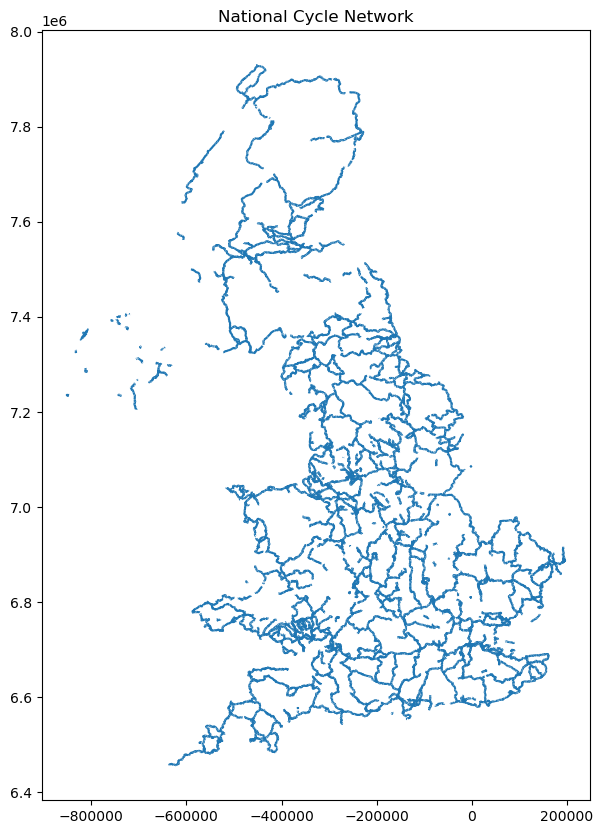

In [44]:
fig, ax = plt.subplots(figsize=(10, 10))

Cycle_Network.plot(ax=ax)

ax.set_title("National Cycle Network")
plt.show()

# Access to health Assets and hazard 

In [45]:
AHAH = pd.read_csv("Raw_data/Access to Healthy Assets & Hazards (AHAH)_2025.csv")

In [46]:
AHAH.head()

,lsoa21cd,GP,bluespace,dentist,fast_food,gambling,greenspace_active,hospital,leisure,pharmacy,...,domain_h_pct,domain_g_rnk,domain_g_pct,domain_e_rnk,domain_e_pct,domain_r_rnk,domain_r_pct,ahah,ahah_rnk,ahah_pct
0,E01000001,1.886601,4.185294,1.003922,0.528431,1.692484,0.592484,4.372222,1.457516,1.077778,...,13,42870,100,43062,100,36982,86,59.865102,42980,100
1,E01000002,1.850000,4.915490,0.634706,0.497059,1.397843,0.558824,3.863922,1.634706,1.428627,...,11,42966,100,43064,100,37500,88,60.988298,42999,100
2,E01000003,2.250000,5.195714,0.872381,0.850952,1.388095,0.411905,3.347143,1.411429,1.019524,...,10,42223,99,43054,100,36677,86,55.800028,42874,100
3,E01000005,2.218924,2.173785,1.273958,0.426389,1.131597,0.642361,1.695660,2.314583,1.115625,...,14,42588,99,43042,100,41964,98,65.849115,43045,100
4,E01000006,0.714286,2.752381,1.997619,1.053571,1.467857,1.345238,10.066667,2.866667,2.085714,...,37,42562,99,42119,98,30484,71,50.186157,42538,99


In [47]:
AHAH.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43064 entries, 0 to 43063
Data columns (total 61 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   lsoa21cd               43064 non-null  object 
 1   GP                     43064 non-null  float64
 2   bluespace              43064 non-null  float64
 3   dentist                43064 non-null  float64
 4   fast_food              43064 non-null  float64
 5   gambling               43064 non-null  float64
 6   greenspace_active      43064 non-null  float64
 7   hospital               43064 non-null  float64
 8   leisure                43064 non-null  float64
 9   pharmacy               43064 non-null  float64
 10  pub_bar                43064 non-null  float64
 11  tobacco                43064 non-null  float64
 12  NO2                    43064 non-null  float64
 13  PM10                   43064 non-null  float64
 14  SO2                    43064 non-null  float64
 15  gr

In [48]:
England_AHAH = AHAH[AHAH['lsoa21cd'].str[0] == 'E']

In [49]:
England_AHAH.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33755 entries, 0 to 33754
Data columns (total 61 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   lsoa21cd               33755 non-null  object 
 1   GP                     33755 non-null  float64
 2   bluespace              33755 non-null  float64
 3   dentist                33755 non-null  float64
 4   fast_food              33755 non-null  float64
 5   gambling               33755 non-null  float64
 6   greenspace_active      33755 non-null  float64
 7   hospital               33755 non-null  float64
 8   leisure                33755 non-null  float64
 9   pharmacy               33755 non-null  float64
 10  pub_bar                33755 non-null  float64
 11  tobacco                33755 non-null  float64
 12  NO2                    33755 non-null  float64
 13  PM10                   33755 non-null  float64
 14  SO2                    33755 non-null  float64
 15  greensp

# Active places

In [50]:
Cycling = pd.read_csv("Raw_data/activeplacescsvs/cycling.csv")

In [51]:
Cycling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 76 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Site ID                                        453 non-null    int64  
 1   Facility Type                                  453 non-null    int64  
 2   Facility Subtype                               453 non-null    int64  
 3   Facility ID                                    453 non-null    int64  
 4   Automatic Start Gate                           287 non-null    float64
 5   Bike Wash                                      77 non-null     float64
 6   Timing System                                  57 non-null     float64
 7   Start Gate                                     287 non-null    float64
 8   No of Persons Start Gate                       64 non-null     float64
 9   Number of Straights                            64 non-

In [52]:
Cycling.head(3)

,Site ID,Facility Type,Facility Subtype,Facility ID,Automatic Start Gate,Bike Wash,Timing System,Start Gate,No of Persons Start Gate,Number of Straights,...,End Month,Closed Date,Closure Reason,Last Updated Date,Meets Active Places Criteria,Easting,Northing,Latitude,Longitude,Created Date
0,1045062,20,20005,30009226,NaN,0.0,NaN,NaN,NaN,NaN,...,12,NaN,NaN,2026-01-06 14:02:10,1,547461,191810,51.60583,0.128027,2017-02-14 12:38:10
1,1002925,20,20002,30009227,NaN,NaN,0.0,NaN,NaN,NaN,...,12,NaN,NaN,2025-04-16 10:50:47,1,523342,211738,51.79071,-0.213026,2017-02-14 12:46:54
2,6003892,20,20004,30009230,0.0,NaN,NaN,0.0,NaN,NaN,...,12,NaN,NaN,2025-12-04 08:39:54,1,435946,547855,54.82427,-1.442053,2017-02-14 12:56:48


In [54]:
Active_places_power_sites = gpd.read_file("Raw_data/GIS_Active_Places_Power_Sites_-4618341622359992723/Site.shp")

In [55]:
Active_places_power_sites.shape

(43522, 80)

In [56]:
Active_places_power_sites.head(3)

,activepart,activepa_1,bikehirefl,buildingna,buildingnu,carparkcap,carparkfla,changingpl,closurerea,corecityna,...,easting,northing,sitealias,ownertypes,management,ownergroup,manageme_1,lat,long,geometry
0,CSP007,Active Lancashire,0,MIDDLETON PARISH COUNCIL SPORTS FIELD,0,20,1,0,0,None,...,342726,458763,None,Sports Club,Sport Club,Sports Club,Others,54.0217,-2.87567,POINT (342726.5 458763.1)
1,CSP020,Active Together,0,None,0,0,0,0,0,None,...,443640,295618,None,Local Authority,Local Authority (in house),Local Authority,Local Authority,52.5567,-1.35773,POINT (443640.85 295618.94)
2,CSP044,Active Gloucestershire,0,STUART PLAYING FIELD,0,40,1,0,0,None,...,387564,200739,OLD RECTORY FIELD,Community Organisation,Community Organisation,Community Organisation,Others,51.7053,-2.18135,POINT (387564.352 200739.08)


In [57]:
Active_places_power_sites.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 43522 entries, 0 to 43521
Data columns (total 80 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   activepart  43522 non-null  object        
 1   activepa_1  43522 non-null  object        
 2   bikehirefl  43522 non-null  int32         
 3   buildingna  12579 non-null  object        
 4   buildingnu  43522 non-null  int64         
 5   carparkcap  43522 non-null  int64         
 6   carparkfla  43522 non-null  int32         
 7   changingpl  43522 non-null  int32         
 8   closurerea  43522 non-null  int32         
 9   corecityna  2764 non-null   object        
 10  countycode  16893 non-null  object        
 11  countyname  16893 non-null  object        
 12  cricketbow  43522 non-null  int32         
 13  cycleparkf  43522 non-null  int32         
 14  dependentl  14752 non-null  object        
 15  dependentt  710 non-null    object        
 16  disability  43

In [58]:
Facilities = gpd.read_file("Raw_data/Active_Power_Places/Facility/Facility_Spatial.shp")

In [59]:
Facilities.head(3)

,siteid,facilityty,facilitysu,facilityid,facstatus,facstatusn,operatorna,openingdat,openingd_1,accessibil,...,recenddate,closurerea,recupdated,meetsapcri,easting,northing,lat,long,recentryda,geometry
0,1004465,Sports Hall,Main,2003947,Closed,None,None,1899-12-30,1899-12-30,Sports Club / Community Association,...,2016-06-06,Strategic Review - facility/site to be replace...,2023-06-02,Yes,252324,147095,51.2039,-4.115280,1899-12-30,POINT (252324.438 147095.078)
1,30008815,Health and Fitness Gym,Health and Fitness Gym,30021366,Operational,None,Everyone Active,1899-12-30,1899-12-30,Registered Membership use,...,1899-12-30,None,2025-07-03,Yes,470632,138109,51.1379,-0.991794,2020-03-16,POINT (470632.219 138109.219)
2,30008815,Swimming Pool,Main/General,30021367,Operational,None,Everyone Active,1899-12-30,1899-12-30,Pay and Play,...,1899-12-30,None,2025-07-03,Yes,470632,138109,51.1379,-0.991794,2020-03-16,POINT (470632.219 138109.219)


In [60]:
Facilities.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 124540 entries, 0 to 124539
Data columns (total 46 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   siteid      124540 non-null  int64         
 1   facilityty  124540 non-null  object        
 2   facilitysu  124540 non-null  object        
 3   facilityid  124540 non-null  int64         
 4   facstatus   124540 non-null  object        
 5   facstatusn  11676 non-null   object        
 6   operatorna  7216 non-null    object        
 7   openingdat  124540 non-null  datetime64[ms]
 8   openingd_1  124540 non-null  datetime64[ms]
 9   accessibil  124540 non-null  object        
 10  accessib_1  124540 non-null  object        
 11  management  124540 non-null  object        
 12  manageme_1  124540 non-null  object        
 13  disability  124540 non-null  object        
 14  disabili_1  124540 non-null  object        
 15  disabili_2  124540 non-null  object        

In [61]:
Facilities.shape

(124540, 46)

In [62]:
Facilities.facilityty.value_counts()

facilityty
Grass Pitches             60375
Sports Hall               14444
Health and Fitness Gym    10722
Studio                     9632
Outdoor Tennis Courts      8231
Artificial Grass Pitch     6743
Swimming Pool              6574
Golf                       3378
Squash Courts              2463
Athletics                   516
Cycling                     450
Indoor Tennis Centre        430
Indoor Bowls                389
Ski Slopes                  140
Ice Rinks                    53
Name: count, dtype: int64

# Access to amenities 

In [63]:
Access_to_amenities = pd.read_excel("Raw_data/accesstoamenitiessportsfacilities (1).xlsx", sheet_name="Table 10",  skiprows=6)

In [64]:
Access_to_amenities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6856 entries, 0 to 6855
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   MSOA code                     6856 non-null   object 
 1   MSOA name                     6856 non-null   object 
 2   Counts                        6856 non-null   int64  
 3   People per facility           6466 non-null   float64
 4   Facilities per 10,000 people  6856 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 267.9+ KB


In [65]:
Access_to_amenities.head()

,MSOA code,MSOA name,Counts,People per facility,"Facilities per 10,000 people"
0,E02000001,City of London 001,86,99.802326,100.198066
1,E02000002,Barking and Dagenham 001,1,8281.000000,1.207584
2,E02000003,Barking and Dagenham 002,5,2308.400000,4.332005
3,E02000004,Barking and Dagenham 003,15,442.666667,22.590361
4,E02000005,Barking and Dagenham 004,2,5541.000000,1.804728
